## Fashion MNIST CNN 학습

- 기존 로지스틱 회귀를 CNN으로 변경

### 1. 라이브러리 로드

In [1]:
# 라이브러리 로드
import torch
import torchvision  # 컴퓨터비젼 모듈
import torchvision.transforms as transforms # 데이터 변환(데이터 전처리)

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt

In [2]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))  # sm_120을 뜻함. 12.0버전

2.12.0+cu130
13.0
NVIDIA GeForce RTX 5060
(12, 0)


### 2. 데이터 전처리

In [72]:
# 데이터 전처리(Transform) 정의
transform = transforms.Compose([
    # 이미지를 Tensor형태로 변환
    transforms.ToTensor(),
    # 정규화, 0 ~ 1 범위값을 -1 ~ 1 범위로 변경
    transforms.Normalize((0.5,), (0.5,))
])

### 3. Fashion MNIST 데이터셋 다운로드(학습 데이터/테스트 데이터)

In [73]:
# 학습데이터
train_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 학습용 데이터셋 사용 여부
    train=True,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform 적용
    transform=transform
)

In [7]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 4. 데이터셋을 학습 데이터로더로 변경

In [8]:
# 학습 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    train_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,  # 2^n이기 때문에 64
    # 데이터를 매 epoch마다 데이터를 섞음
    shuffle=True
)

In [9]:
train_loader

### 5. 테스트 데이터셋 다운로드

In [10]:
# 테스트데이터
test_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 테스트 데이터(학습용 데이터셋 사용 여부)
    train=False,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform 적용
    transform=transform
)

In [11]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

### 6. 테스트 데이터로더 생성

In [12]:
# 테스트 데이터로더 생성
test_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    test_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,  # 2^n이기 때문에 64
    # 테스트 데이터는 섞을 필요없음
    shuffle=False
)

In [13]:
test_loader

### 7. PyTorch GPU 사용가능 여부확인

- Compute Unified Device Architecture : NVIDIA가 제공하는 GPU 병렬컴퓨팅 플랫폼

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cuda


### 8. Fashion MNIST 클래스(분류) 이름 지정

In [15]:
classes = [
    'T-shirt/top',  # 티셔츠
    'Trouser',      # 바지
    'Pullover',     # 풀오버
    'Dress',        # 드레스
    'Coat',         # 코트
    'Sandal',       # 샌들
    'Shirt',        # 셔츠
    'Sneaker',      # 스니커즈
    'Bag',          # 가방
    'Ankle boot'    # 발목부츠
]

### 9. 이미지 확인

Tensor shape : torch.Size([1, 28, 28])
Label : 1
Class name : Trouser


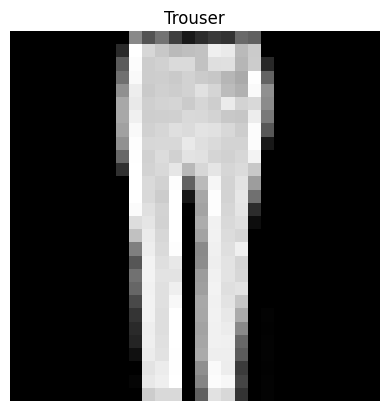

In [16]:
import matplotlib.pyplot as plt # matplotlib 차트에 이미지 출력

# 데이터셋에서 첫번째 데이터
image, label = train_dataset[129]

print(f'Tensor shape : {image.shape}')
print(f'Label : {label}')
print(f'Class name : {classes[label]}')

# 정규화 복원
# 현재 범위가 -1 ~ 1 범위로 정규화한걸 다시 복원
# 굳이 필요없음
image = image * 0.5 + 0.5

# 이미지 출력
# [1, 28, 28] -> [28, 28]
image = image.squeeze() # 1차원 제거

plt.imshow(image, cmap='gray')
plt.title(classes[label])
plt.axis('off')
plt.show()

### 10. CNN 모델 클래스 선언

- CNN 사용

In [66]:
# CNN 모델 클래스
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. 특징 추출
        self.features = nn.Sequential(
            ## 첫번째 합성곱
            # batch size(batch 개수) = 64
            # 입력이미지 : [batch, 1, 28, 28]
            # 합성곱 결과 : [batch, 32, 28, 28]
            # padding=1을 넣지 않으면 [batch, 32, 26, 26]으로 변경
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,  # 3 X 3
                padding=1   # 1픽셀 여백추가
            ),
            nn.ReLU(),  # 활성화함수 통과
            # 이미지크기 절반 축소
            # [batch, 32, 28, 28] -> [batch, 32 ,14 ,14]
            nn.MaxPool2d(kernel_size=2, stride=2),

            ## 두번째 합성곱
            # [batch, 32, 14, 14] -> [batch, 64, 14, 14]
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),  # 활성화함수 통과
            # 이미지크기 절반 축소
            # [batch, 64, 14, 14] -> [batch, 64, 7, 7]
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # 2. 분류
        self.classifier = nn.Sequential(
            # 3차원 특징맵을 1차원 벡터 변환
            # [batch, 64, 7, 7] -> [batch, 64 *7*7(3136)]
            nn.Flatten(),   # 이 코드하나면 신경 쓸 필요없음

            # 완전연결층 생성
            nn.Linear(64*7*7, 128),
            nn.ReLU(),

            # 과적합 방지
            nn.Dropout(0.3),    # 30% 날려서 걸러내기

            # 최종 출력층 생성
            # FashionMNIST 10개 클래스
            nn.Linear(128, 10)
        )

    def forward(self, x):
        # 이미지 특징 추출
        x = self.features(x)

        # 분류
        return self.classifier(x)

### 11. 모델 객체 생성

In [67]:
model = CNN().to(device)

In [68]:
model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

### 12. 손실함수 정의

In [69]:
# 다중 클래스 분류에 사용하는 손실함수
loss_fn = nn.CrossEntropyLoss()

### 13. 최적화 알고리즘 정의

- Adam

In [70]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

### 14. 모델 학습

In [22]:
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader: # 64번 반복
        # GPU로 이동(더 빠르게 하기 위해 추가)
        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측값 계산
        outputs = model(images)

        # 손실 계산
        loss = loss_fn(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이터
        optimizer.step()

        # 현재 batch(64) 손실값을 누적
        running_loss += loss.item()

    # 평균 손실 구하기
    avg_loss = running_loss / len(train_loader)

    print(f'[Epoch {epoch + 1}/{num_epochs}] Loss : {avg_loss:.4f}')

[Epoch 1/50] Loss : 0.5037
[Epoch 2/50] Loss : 0.3215
[Epoch 3/50] Loss : 0.2758
[Epoch 4/50] Loss : 0.2461
[Epoch 5/50] Loss : 0.2237
[Epoch 6/50] Loss : 0.2029
[Epoch 7/50] Loss : 0.1863
[Epoch 8/50] Loss : 0.1712
[Epoch 9/50] Loss : 0.1564
[Epoch 10/50] Loss : 0.1462
[Epoch 11/50] Loss : 0.1326
[Epoch 12/50] Loss : 0.1249
[Epoch 13/50] Loss : 0.1163
[Epoch 14/50] Loss : 0.1069
[Epoch 15/50] Loss : 0.1003
[Epoch 16/50] Loss : 0.0920
[Epoch 17/50] Loss : 0.0881
[Epoch 18/50] Loss : 0.0832
[Epoch 19/50] Loss : 0.0794
[Epoch 20/50] Loss : 0.0760
[Epoch 21/50] Loss : 0.0707
[Epoch 22/50] Loss : 0.0686
[Epoch 23/50] Loss : 0.0673
[Epoch 24/50] Loss : 0.0639
[Epoch 25/50] Loss : 0.0612
[Epoch 26/50] Loss : 0.0597
[Epoch 27/50] Loss : 0.0573
[Epoch 28/50] Loss : 0.0551
[Epoch 29/50] Loss : 0.0561
[Epoch 30/50] Loss : 0.0515
[Epoch 31/50] Loss : 0.0516
[Epoch 32/50] Loss : 0.0491
[Epoch 33/50] Loss : 0.0521
[Epoch 34/50] Loss : 0.0456
[Epoch 35/50] Loss : 0.0441
[Epoch 36/50] Loss : 0.0446
[

### 15. 모델 평가(테스트)

In [23]:
model.eval()

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [24]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 예측
        outputs = model(images)

        # 가장 높은 확률 선택
        _, pred = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (pred == labels).sum().item()

accuracy = 100 * (correct / total)

print(f'\n테스트 정확도 : {accuracy:.2f}%')


테스트 정확도 : 91.85%


### 16. 마지막 예측 테스트

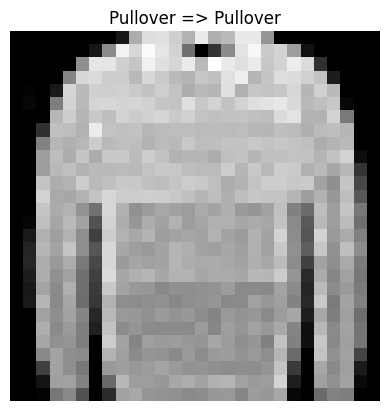

실제 답 : Pullover, 예측 결과 : Pullover


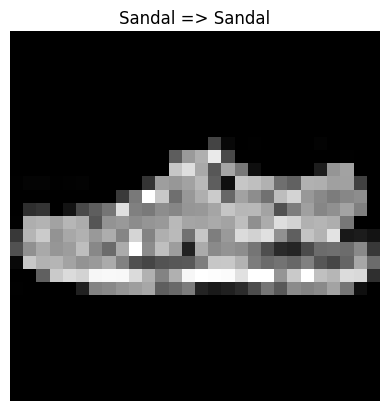

실제 답 : Sandal, 예측 결과 : Sandal


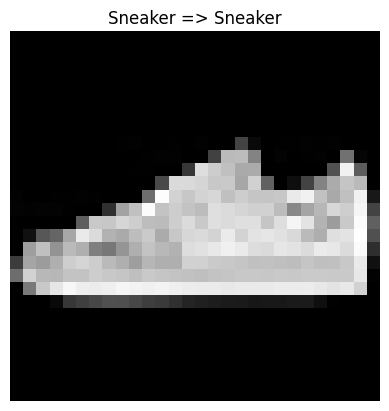

실제 답 : Sneaker, 예측 결과 : Sneaker


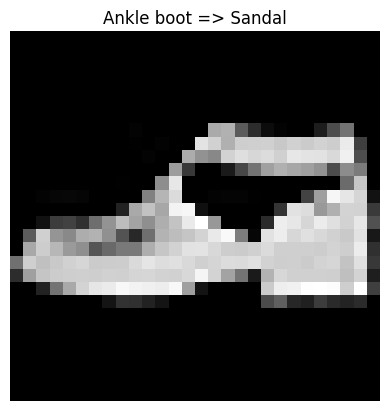

실제 답 : Ankle boot, 예측 결과 : Sandal


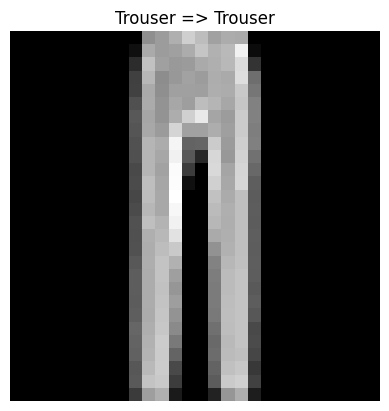

실제 답 : Trouser, 예측 결과 : Trouser


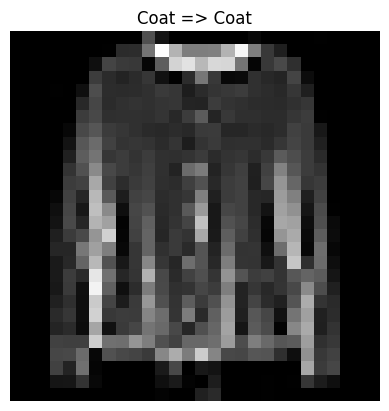

실제 답 : Coat, 예측 결과 : Coat


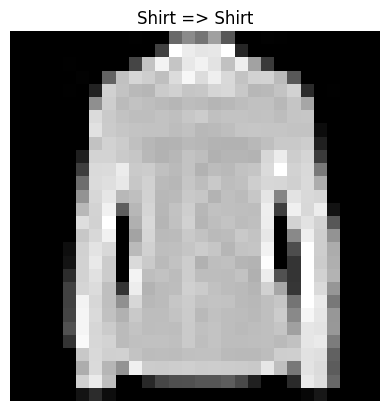

실제 답 : Shirt, 예측 결과 : Shirt


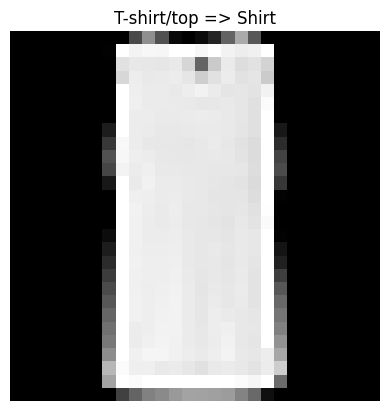

실제 답 : T-shirt/top, 예측 결과 : Shirt


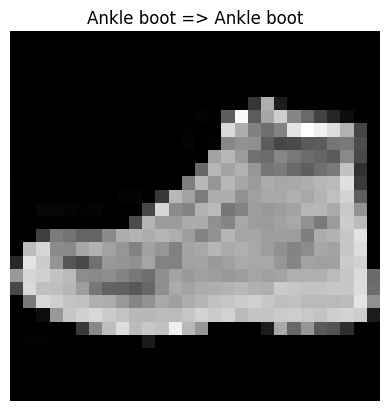

실제 답 : Ankle boot, 예측 결과 : Ankle boot


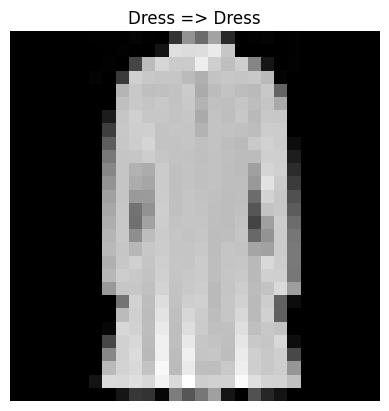

실제 답 : Dress, 예측 결과 : Dress


In [25]:
for i in range(20, 30):
    image, label = test_dataset[i]

    with torch.no_grad():
        # 차원 추가
        test_input = image.unsqueeze(0).to(device)

        # 출력
        output = model(test_input)

        predicted = torch.argmax(output, dim = 1).item()

        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'{classes[label]} => {classes[predicted]}')
        plt.axis('off')
        plt.show()

    print(f'실제 답 : {classes[label]}, 예측 결과 : {classes[predicted]}')

### 17. 모델저장

In [26]:
torch.save(model.state_dict(), 'fashionMNIST_cnn.pth')

### 18. 모델 성능 끌어올리기

- 데이터 증강 추가
- CNN 모델 성능 올리기
- 최적화 알고리즘 변경
- 학습횟수 epoch 증가

In [ ]:
# 1. 데이터 증강 추가 - 학습용 트랜스폼 변경
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),     # 좌우반전
    transforms.RandomRotation(10),  # 회전
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)    # 이동
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [35]:
# 학습데이터
train_dataset = torchvision.datasets.FashionMNIST(
    # 데이터 저장경로
    root='./data',
    # 학습용 데이터셋 사용 여부
    train=True,
    # 로컬에 데이터가 없으면 자동 다운로드
    download=True,
    # transform 적용
    transform=train_transform
)

In [36]:
# 학습 데이터로더 생성
train_loader = torch.utils.data.DataLoader(
    # 사용할 데이터셋 지정
    train_dataset,
    # 한번에 가져올 데이터개수 지정
    batch_size=64,  # 2^n이기 때문에 64
    # 데이터를 매 epoch마다 데이터를 섞음
    shuffle=True
)

In [76]:
# 2. CNN 모델 성능 올리기
## 실패한 방법 - 원래 모델로 돌려서 사용

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. 특징 추출
        self.features = nn.Sequential(
            ## 첫번째 합성곱
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,  # 3 X 3
                padding=1   # 1픽셀 여백추가
            ),
            nn.BatchNorm2d(32), # 정규화
            nn.ReLU(),  # 활성화함수 통과
            # 이미지크기 절반 축소
            nn.MaxPool2d(kernel_size=2, stride=2),

            ## 두번째 합성곱
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64), # 정규화
            nn.ReLU(),  # 활성화함수 통과
            # 이미지크기 절반 축소
            nn.MaxPool2d(kernel_size=2, stride=2),   # 64*7*7
        )

        # 2. 분류
        self.classifier = nn.Sequential(
            # 3차원 특징맵을 1차원 벡터 변환
            nn.Flatten(),

            # 완전연결층 생성
            nn.Linear(64*7*7, 128),
            nn.ReLU(),

            # 과적합 방지
            nn.Dropout(0.3),    # 30% 날려서 걸러내기

            # 최종 출력층 생성
            nn.Linear(128, 10)
        )

    def forward(self, x):
        # 이미지 특징 추출
        x = self.features(x)

        # 분류
        return self.classifier(x)

In [77]:
model = CNN().to(device)
model

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [78]:
# 4. 학습횟수 증가 epoch를 15회 이상
num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader: # 64번 반복
        # GPU로 이동(더 빠르게 하기 위해 추가)
        images = images.to(device)
        labels = labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 예측값 계산
        outputs = model(images)

        # 손실 계산
        loss = loss_fn(outputs, labels)

        # 역전파
        loss.backward()

        # 가중치 업데이터
        optimizer.step()

        # 현재 batch(64) 손실값을 누적
        running_loss += loss.item()

    # 평균 손실 구하기
    avg_loss = running_loss / len(train_loader)

    print(f'[Epoch {epoch + 1}/{num_epochs}] Loss : {avg_loss:.4f}')

[Epoch 1/15] Loss : 2.3564
[Epoch 2/15] Loss : 2.3549
[Epoch 3/15] Loss : 2.3547
[Epoch 4/15] Loss : 2.3555
[Epoch 5/15] Loss : 2.3554
[Epoch 6/15] Loss : 2.3569
[Epoch 7/15] Loss : 2.3553
[Epoch 8/15] Loss : 2.3565
[Epoch 9/15] Loss : 2.3557
[Epoch 10/15] Loss : 2.3568
[Epoch 11/15] Loss : 2.3563
[Epoch 12/15] Loss : 2.3566
[Epoch 13/15] Loss : 2.3558
[Epoch 14/15] Loss : 2.3568
[Epoch 15/15] Loss : 2.3558


In [74]:
# 3. 최적화 알고리즘 변경

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

- Loss가 0.2에서 0.1사이로 나오는 게 가장 좋음
- ex) 0.05 과적합!